# Portfolio Comparison Workflow
Compare original portfolio vs optimized portfolio with full statistics and visualizations

## Setup

In [19]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from app.core.agentic_framework.tool_lib.agent_specific_tools.optimizer import get_user_portfolio
from app.utils.gpt_parser import canonical_portfolio
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from app.core.calculations.returns.calculator import ReturnsCalculator, PortfolioReturnsCalculator
from app.core.calculations.performance.calculator import PerformanceCalculator
from app.core.calculations.risk.calculator import RiskCalculator
from app.repositories.price_data import fetch_bulk_price_data_for_tickers
import matplotlib.pyplot as plt
import yaml

## Step 1: Get User Portfolio

In [20]:
# Get user portfolio from database
result = get_user_portfolio()
parsed = yaml.safe_load(result)

if not parsed['success']:
    raise Exception(f"Failed to get user portfolio: {parsed['error']}")

user_portfolio = parsed['data']
print(f"Retrieved user portfolio with {len(user_portfolio)} positions")
print(f"Positions: {list(user_portfolio.keys())}")

Retrieved user portfolio with 35 positions
Positions: ['AEE', 'APP', 'ARM', 'AVGO', 'BSX', 'CEG', 'CMS', 'CRDO', 'DGNX', 'EIS', 'EMQQ', 'EQIX', 'EXOD', 'FITB', 'FR', 'FUFU', 'GREK', 'IGSB', 'IIPR', 'INTR', 'JPM', 'MTSI', 'MU', 'NLR', 'NRG', 'NU', 'NVDA', 'OKLO', 'PLTR', 'SGDM', 'SLVR', 'STAG', 'TRNO', 'VCSH', 'WEC']


## Step 2: Normalize User Portfolio

In [21]:
# Normalize using canonical_portfolio
original_portfolio = canonical_portfolio(user_portfolio)
print(f"\nNormalized original portfolio:")
print(f"Total positions: {len(original_portfolio)}")
print(f"Total allocation: {sum(p['allocation'] for p in original_portfolio.values()):.2%}")
print(f"\nSample positions:")
for ticker, data in list(original_portfolio.items())[:3]:
    print(f"  {ticker}: {data['allocation']:.2%} ({data['position']})")


Normalized original portfolio:
Total positions: 35
Total allocation: 93.10%

Sample positions:
  AEE: 1.50% (long)
  APP: 4.20% (long)
  ARM: 2.60% (long)


## Step 3: Enter Optimized Portfolio

**ENTER YOUR OPTIMIZED PORTFOLIO IN THE CELL BELOW**

Format options:
- Agent output format: `{"portfolio": [{"ticker": "AAPL", "allocation": 0.1, "position": "long"}, ...]}`
- Dictionary format: `{"AAPL": {"allocation": 0.1, "position": "long"}, ...}`

In [22]:
optimized_portfolio_raw = {"portfolio": [{"ticker": "NVDA", "allocation": 0.055, "position": "long", "changes_from_original": "Reduced from 0.065 to 0.055 to manage concentration/correlation."}, {"ticker": "APP", "allocation": 0.035, "position": "long", "changes_from_original": "Reduced from 0.042 to 0.035 for crowding and sector risk."}, {"ticker": "AVGO", "allocation": 0.033, "position": "long", "changes_from_original": "Unchanged from original position."}, {"ticker": "BSX", "allocation": 0.05, "position": "long", "changes_from_original": "Slightly reduced on strong performance and to diversify."}, {"ticker": "JPM", "allocation": 0.04, "position": "long", "changes_from_original": "Unchanged from original position."}, {"ticker": "MU", "allocation": 0.014, "position": "long", "changes_from_original": "Slightly trimmed to balance sector exposure."}, {"ticker": "PLTR", "allocation": 0.022, "position": "long", "changes_from_original": "Trimmed to reduce tech concentration."}, {"ticker": "NRG", "allocation": 0.045, "position": "long", "changes_from_original": "Reduced from 0.055 to 0.045 to diversify away from recent rally."}, {"ticker": "SLVR", "allocation": 0.032, "position": "long", "changes_from_original": "Unchanged from original position."}, {"ticker": "SGDM", "allocation": 0.014, "position": "long", "changes_from_original": "Reduced for overall risk balance."}, {"ticker": "CEG", "allocation": 0.021, "position": "long", "changes_from_original": "Minor adjustment for balance with CMS and NRG."}, {"ticker": "CMS", "allocation": 0.03, "position": "long", "changes_from_original": "Adjusted to retain exposure but make room for new additions."}, {"ticker": "NLR", "allocation": 0.016, "position": "long", "changes_from_original": "Reduced to allow for international and commodity diversity."}, {"ticker": "GREK", "allocation": 0.018, "position": "long", "changes_from_original": "Unchanged from original position."}, {"ticker": "HRTG", "allocation": 0.02, "position": "long", "changes_from_original": "Added for positive idiosyncratic alpha, insurance diversification, strong Sharpe/alpha."}, {"ticker": "CALM", "allocation": 0.03, "position": "long", "changes_from_original": "Added for food/agriculture/defensive quality tilt, low correlation, dividend/yield focus."}, {"ticker": "IDXX", "allocation": 0.03, "position": "long", "changes_from_original": "Added for global health care breadth, high profitability, non-tech quality allocation."}]}

# Normalize optimized portfolio
optimized_portfolio = canonical_portfolio(optimized_portfolio_raw)
print(f"Normalized optimized portfolio:")
print(f"Total positions: {len(optimized_portfolio)}")
print(f"Total allocation: {sum(p['allocation'] for p in optimized_portfolio.values()):.2%}")

Normalized optimized portfolio:
Total positions: 17
Total allocation: 50.50%


## Step 4: Calculate Portfolio Statistics

In [23]:
def calculate_portfolio_stats(portfolio, start_date, end_date, portfolio_name="Portfolio"):
    """Calculate comprehensive portfolio statistics"""
    
    # Convert portfolio to weights dict
    weights = {}
    for ticker, data in portfolio.items():
        position = data["position"]
        allocation = data["allocation"]
        weights[ticker] = allocation if position.lower() == "long" else -allocation
    
    # Print portfolio summary
    print(f"\n{'='*60}")
    print(f"{portfolio_name.upper()} SUMMARY")
    print(f"{'='*60}")
    print(f"Total positions: {len(weights)}")
    print(f"Long positions: {sum(1 for w in weights.values() if w > 0)}")
    print(f"Short positions: {sum(1 for w in weights.values() if w < 0)}")
    print(f"Net exposure: {sum(weights.values()):.2%}")
    print(f"Gross exposure: {sum(abs(w) for w in weights.values()):.2%}")
    
    # Fetch price data
    all_tickers = list(weights.keys()) + ["SPY"]
    start_str = start_date.strftime('%Y-%m-%d')
    end_str = end_date.strftime('%Y-%m-%d')
    
    print(f"\nFetching price data from {start_str} to {end_str}...")
    ticker_closes = fetch_bulk_price_data_for_tickers(all_tickers, start_str, end_str, frequency='daily')
    print(f"Fetched data for {len(ticker_closes)} tickers")
    
    # Calculate returns
    ticker_price_returns = {
        t: ReturnsCalculator.daily_price_returns(ticker_closes[t])
        for t in weights if t in ticker_closes
    }
    
    portfolio_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
        ticker_price_returns, weights, dropna=False
    )
    
    # Calculate metrics
    annualized_return = ReturnsCalculator.annualized_return(portfolio_daily_returns, trading_days=252)
    annual_volatility = RiskCalculator.annualized_volatility(portfolio_daily_returns, trading_days=252)
    sharpe_ratio = PerformanceCalculator.sharpe_ratio(portfolio_daily_returns, periods_per_year=252)
    
    # Calculate alpha and beta vs SPY
    if "SPY" in ticker_closes:
        spy_returns = ReturnsCalculator.daily_price_returns(ticker_closes["SPY"])
        alpha = PerformanceCalculator.alpha_jensen(portfolio_daily_returns, spy_returns, periods_per_year=252)
        beta = RiskCalculator.beta(asset_daily_returns=portfolio_daily_returns, market_daily_returns=spy_returns)
    else:
        spy_returns = None
        alpha = np.nan
        beta = np.nan
    
    # Calculate drawdown
    cumulative_returns = (1 + portfolio_daily_returns).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns / running_max - 1.0)
    max_drawdown = drawdown.min()
    
    # Print metrics
    print(f"\n{'='*60}")
    print(f"{portfolio_name.upper()} PERFORMANCE METRICS")
    print(f"{'='*60}")
    print(f"Annualized Return:     {annualized_return:>8.2%}")
    print(f"Annual Volatility:     {annual_volatility:>8.2%}")
    print(f"Sharpe Ratio:          {sharpe_ratio:>8.2f}")
    print(f"Max Drawdown:          {max_drawdown:>8.2%}")
    print(f"Alpha vs SPY:          {alpha:>8.2%}")
    print(f"Beta vs SPY:           {beta:>8.2f}")
    print(f"{'='*60}")
    
    return {
        'weights': weights,
        'daily_returns': portfolio_daily_returns,
        'cumulative_returns': cumulative_returns,
        'drawdown': drawdown,
        'ticker_closes': ticker_closes,
        'spy_returns': spy_returns,
        'metrics': {
            'annualized_return': annualized_return,
            'annual_volatility': annual_volatility,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown,
            'alpha': alpha,
            'beta': beta
        }
    }

In [24]:
# Define time period for analysis
start_date = datetime(2023, 9, 30)
end_date = datetime.now()

# Calculate statistics for both portfolios
original_stats = calculate_portfolio_stats(original_portfolio, start_date, end_date, "Original Portfolio")
optimized_stats = calculate_portfolio_stats(optimized_portfolio, start_date, end_date, "Optimized Portfolio")


ORIGINAL PORTFOLIO SUMMARY
Total positions: 35
Long positions: 35
Short positions: 0
Net exposure: 93.10%
Gross exposure: 93.10%

Fetching price data from 2023-09-30 to 2025-10-06...
Fetched data for 36 tickers

ORIGINAL PORTFOLIO PERFORMANCE METRICS
Annualized Return:       89.97%
Annual Volatility:       26.59%
Sharpe Ratio:              2.39
Max Drawdown:           -20.65%
Alpha vs SPY:            41.54%
Beta vs SPY:               1.11

OPTIMIZED PORTFOLIO SUMMARY
Total positions: 17
Long positions: 17
Short positions: 0
Net exposure: 50.50%
Gross exposure: 50.50%

Fetching price data from 2023-09-30 to 2025-10-06...
Fetched data for 18 tickers

OPTIMIZED PORTFOLIO PERFORMANCE METRICS
Annualized Return:       39.59%
Annual Volatility:       11.87%
Sharpe Ratio:              2.54
Max Drawdown:           -11.99%
Alpha vs SPY:            17.45%
Beta vs SPY:               0.64


## Step 5: Compare Statistics Side-by-Side

In [25]:
# Print comparison table
print("\n" + "="*80)
print("PORTFOLIO COMPARISON")
print("="*80)
print(f"{'Metric':<30s} {'Original':>15s} {'Optimized':>15s} {'Difference':>15s}")
print("-"*80)

orig_m = original_stats['metrics']
opt_m = optimized_stats['metrics']

print(f"{'Annualized Return':<30s} {orig_m['annualized_return']:>14.2%} {opt_m['annualized_return']:>14.2%} {opt_m['annualized_return']-orig_m['annualized_return']:>14.2%}")
print(f"{'Annual Volatility':<30s} {orig_m['annual_volatility']:>14.2%} {opt_m['annual_volatility']:>14.2%} {opt_m['annual_volatility']-orig_m['annual_volatility']:>14.2%}")
print(f"{'Sharpe Ratio':<30s} {orig_m['sharpe_ratio']:>14.2f} {opt_m['sharpe_ratio']:>14.2f} {opt_m['sharpe_ratio']-orig_m['sharpe_ratio']:>14.2f}")
print(f"{'Max Drawdown':<30s} {orig_m['max_drawdown']:>14.2%} {opt_m['max_drawdown']:>14.2%} {opt_m['max_drawdown']-orig_m['max_drawdown']:>14.2%}")
print(f"{'Alpha vs SPY':<30s} {orig_m['alpha']:>14.2%} {opt_m['alpha']:>14.2%} {opt_m['alpha']-orig_m['alpha']:>14.2%}")
print(f"{'Beta vs SPY':<30s} {orig_m['beta']:>14.2f} {opt_m['beta']:>14.2f} {opt_m['beta']-orig_m['beta']:>14.2f}")

print("\n" + "-"*80)
print(f"{'Net Exposure':<30s} {sum(original_stats['weights'].values()):>14.2%} {sum(optimized_stats['weights'].values()):>14.2%}")
print(f"{'Gross Exposure':<30s} {sum(abs(w) for w in original_stats['weights'].values()):>14.2%} {sum(abs(w) for w in optimized_stats['weights'].values()):>14.2%}")
print(f"{'Number of Positions':<30s} {len(original_stats['weights']):>14d} {len(optimized_stats['weights']):>14d}")
print("="*80)


PORTFOLIO COMPARISON
Metric                                Original       Optimized      Difference
--------------------------------------------------------------------------------
Annualized Return                      89.97%         39.59%        -50.38%
Annual Volatility                      26.59%         11.87%        -14.72%
Sharpe Ratio                             2.39           2.54           0.15
Max Drawdown                          -20.65%        -11.99%          8.66%
Alpha vs SPY                           41.54%         17.45%        -24.09%
Beta vs SPY                              1.11           0.64          -0.47

--------------------------------------------------------------------------------
Net Exposure                           93.10%         50.50%
Gross Exposure                         93.10%         50.50%
Number of Positions                        35             17


## Step 6: Visualize Comparison

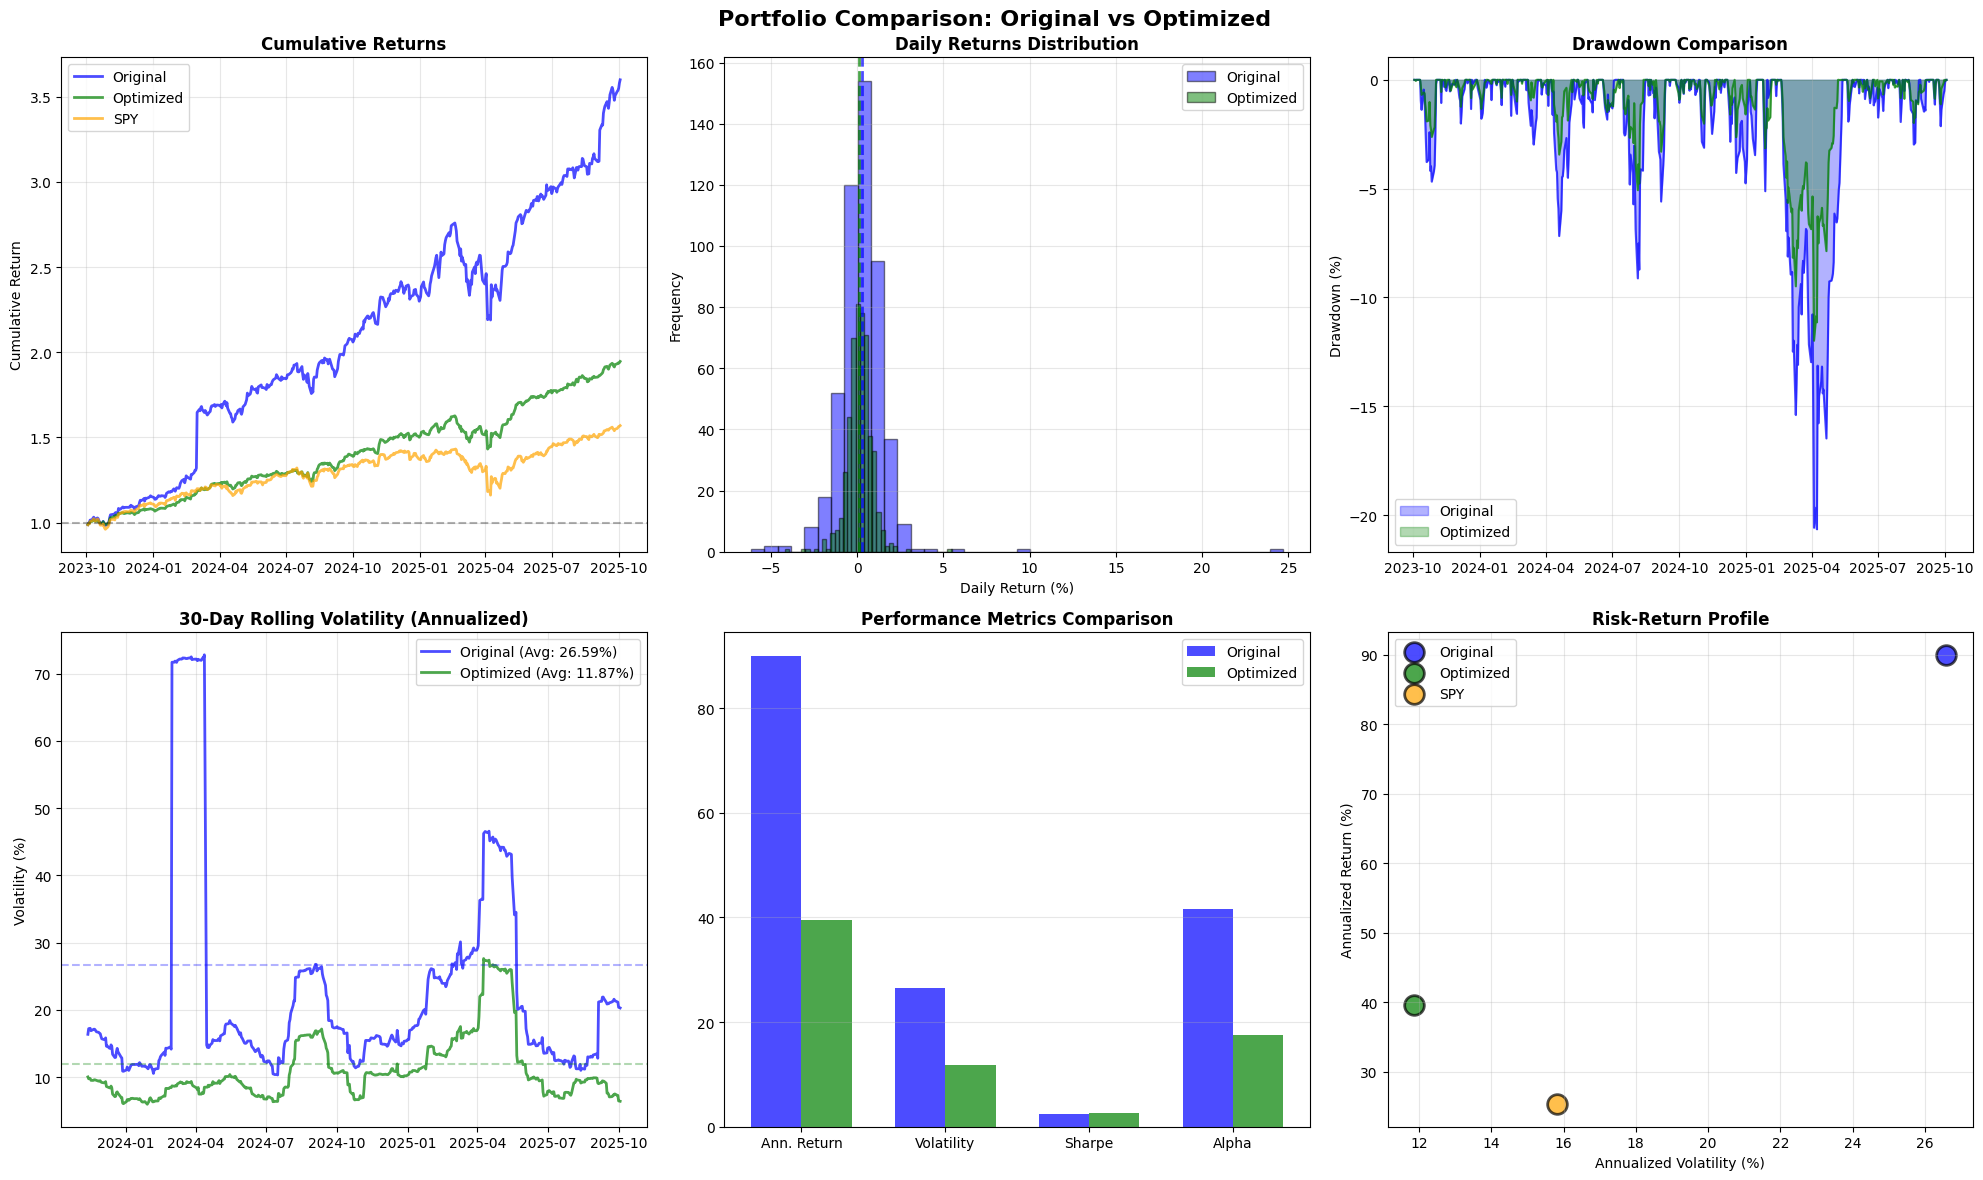

In [26]:
# Create comprehensive comparison visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Portfolio Comparison: Original vs Optimized', fontsize=16, fontweight='bold')

# 1. Cumulative Returns
ax1 = axes[0, 0]
ax1.plot(original_stats['cumulative_returns'].index, original_stats['cumulative_returns'].values,
         linewidth=2, color='blue', label='Original', alpha=0.7)
ax1.plot(optimized_stats['cumulative_returns'].index, optimized_stats['cumulative_returns'].values,
         linewidth=2, color='green', label='Optimized', alpha=0.7)
if original_stats['spy_returns'] is not None:
    spy_cumulative = (1 + original_stats['spy_returns']).cumprod()
    ax1.plot(spy_cumulative.index, spy_cumulative.values,
             linewidth=2, color='orange', label='SPY', alpha=0.7)
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)
ax1.set_title('Cumulative Returns', fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Daily Returns Distribution
ax2 = axes[0, 1]
ax2.hist(original_stats['daily_returns'].dropna() * 100, bins=40, alpha=0.5,
         color='blue', edgecolor='black', label='Original')
ax2.hist(optimized_stats['daily_returns'].dropna() * 100, bins=40, alpha=0.5,
         color='green', edgecolor='black', label='Optimized')
ax2.axvline(original_stats['daily_returns'].mean() * 100, color='blue',
            linestyle='--', linewidth=2, alpha=0.7)
ax2.axvline(optimized_stats['daily_returns'].mean() * 100, color='green',
            linestyle='--', linewidth=2, alpha=0.7)
ax2.set_title('Daily Returns Distribution', fontweight='bold')
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Drawdown Comparison
ax3 = axes[0, 2]
ax3.fill_between(original_stats['drawdown'].index, original_stats['drawdown'].values * 100, 0,
                  alpha=0.3, color='blue', label='Original')
ax3.plot(original_stats['drawdown'].index, original_stats['drawdown'].values * 100,
         linewidth=1.5, color='blue', alpha=0.7)
ax3.fill_between(optimized_stats['drawdown'].index, optimized_stats['drawdown'].values * 100, 0,
                  alpha=0.3, color='green', label='Optimized')
ax3.plot(optimized_stats['drawdown'].index, optimized_stats['drawdown'].values * 100,
         linewidth=1.5, color='green', alpha=0.7)
ax3.set_title('Drawdown Comparison', fontweight='bold')
ax3.set_ylabel('Drawdown (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Rolling Volatility (30-day)
ax4 = axes[1, 0]
rolling_vol_orig = original_stats['daily_returns'].rolling(window=30).std() * np.sqrt(252) * 100
rolling_vol_opt = optimized_stats['daily_returns'].rolling(window=30).std() * np.sqrt(252) * 100
ax4.plot(rolling_vol_orig.index, rolling_vol_orig.values, linewidth=2, color='blue',
         label=f"Original (Avg: {orig_m['annual_volatility']*100:.2f}%)", alpha=0.7)
ax4.plot(rolling_vol_opt.index, rolling_vol_opt.values, linewidth=2, color='green',
         label=f"Optimized (Avg: {opt_m['annual_volatility']*100:.2f}%)", alpha=0.7)
ax4.axhline(y=orig_m['annual_volatility'] * 100, color='blue', linestyle='--', alpha=0.3)
ax4.axhline(y=opt_m['annual_volatility'] * 100, color='green', linestyle='--', alpha=0.3)
ax4.set_title('30-Day Rolling Volatility (Annualized)', fontweight='bold')
ax4.set_ylabel('Volatility (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Performance Metrics Bar Chart
ax5 = axes[1, 1]
metrics = ['Ann. Return', 'Volatility', 'Sharpe', 'Alpha']
orig_values = [orig_m['annualized_return']*100, orig_m['annual_volatility']*100,
               orig_m['sharpe_ratio'], orig_m['alpha']*100]
opt_values = [opt_m['annualized_return']*100, opt_m['annual_volatility']*100,
              opt_m['sharpe_ratio'], opt_m['alpha']*100]
x = np.arange(len(metrics))
width = 0.35
ax5.bar(x - width/2, orig_values, width, label='Original', color='blue', alpha=0.7)
ax5.bar(x + width/2, opt_values, width, label='Optimized', color='green', alpha=0.7)
ax5.set_title('Performance Metrics Comparison', fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(metrics)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Risk-Return Scatter
ax6 = axes[1, 2]
ax6.scatter(orig_m['annual_volatility']*100, orig_m['annualized_return']*100,
            s=200, color='blue', alpha=0.7, label='Original', edgecolors='black', linewidths=2)
ax6.scatter(opt_m['annual_volatility']*100, opt_m['annualized_return']*100,
            s=200, color='green', alpha=0.7, label='Optimized', edgecolors='black', linewidths=2)
if original_stats['spy_returns'] is not None:
    spy_ret = ReturnsCalculator.annualized_return(original_stats['spy_returns'], trading_days=252)
    spy_vol = RiskCalculator.annualized_volatility(original_stats['spy_returns'], trading_days=252)
    ax6.scatter(spy_vol*100, spy_ret*100, s=200, color='orange', alpha=0.7,
                label='SPY', edgecolors='black', linewidths=2)
ax6.set_title('Risk-Return Profile', fontweight='bold')
ax6.set_xlabel('Annualized Volatility (%)')
ax6.set_ylabel('Annualized Return (%)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Position-Level Comparison

In [27]:
# Compare positions between portfolios
print("\n" + "="*80)
print("POSITION-LEVEL COMPARISON")
print("="*80)

# Get all unique tickers
all_tickers = sorted(set(list(original_stats['weights'].keys()) + list(optimized_stats['weights'].keys())))

print(f"\n{'Ticker':<8s} {'Original':<12s} {'Optimized':<12s} {'Change':<12s} {'Status':<15s}")
print("-"*80)

for ticker in all_tickers:
    orig_weight = original_stats['weights'].get(ticker, 0)
    opt_weight = optimized_stats['weights'].get(ticker, 0)
    change = opt_weight - orig_weight
    
    if orig_weight == 0:
        status = "NEW"
    elif opt_weight == 0:
        status = "REMOVED"
    elif abs(change) > 0.001:
        status = "MODIFIED"
    else:
        status = "UNCHANGED"
    
    print(f"{ticker:<8s} {orig_weight:>11.2%} {opt_weight:>11.2%} {change:>11.2%} {status:<15s}")

print("="*80)

# Summary statistics
new_positions = sum(1 for t in all_tickers if original_stats['weights'].get(t, 0) == 0 and optimized_stats['weights'].get(t, 0) != 0)
removed_positions = sum(1 for t in all_tickers if original_stats['weights'].get(t, 0) != 0 and optimized_stats['weights'].get(t, 0) == 0)
modified_positions = sum(1 for t in all_tickers if abs(optimized_stats['weights'].get(t, 0) - original_stats['weights'].get(t, 0)) > 0.001 and original_stats['weights'].get(t, 0) != 0 and optimized_stats['weights'].get(t, 0) != 0)

print(f"\nSummary:")
print(f"  New positions: {new_positions}")
print(f"  Removed positions: {removed_positions}")
print(f"  Modified positions: {modified_positions}")
print(f"  Total changes: {new_positions + removed_positions + modified_positions}")


POSITION-LEVEL COMPARISON

Ticker   Original     Optimized    Change       Status         
--------------------------------------------------------------------------------
AEE            1.50%       0.00%      -1.50% REMOVED        
APP            4.20%       3.50%      -0.70% MODIFIED       
ARM            2.60%       0.00%      -2.60% REMOVED        
AVGO           3.40%       3.30%      -0.10% MODIFIED       
BSX            5.10%       5.00%      -0.10% UNCHANGED      
CALM           0.00%       3.00%       3.00% NEW            
CEG            2.50%       2.10%      -0.40% MODIFIED       
CMS            3.60%       3.00%      -0.60% MODIFIED       
CRDO           1.20%       0.00%      -1.20% REMOVED        
DGNX           0.90%       0.00%      -0.90% REMOVED        
EIS            3.70%       0.00%      -3.70% REMOVED        
EMQQ           1.30%       0.00%      -1.30% REMOVED        
EQIX           8.10%       0.00%      -8.10% REMOVED        
EXOD           1.30%       0.00%  